# Exploratory Data Analysis (EDA)


### Used libraries:

In [113]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from pathlib import Path
import shutil
from tqdm import tqdm
from datetime import datetime

### 1. Data ingestion

In [2]:
dataset = "elemento/nyc-yellow-taxi-trip-data"
file = "yellow_tripdata_2015-01.csv"
bronze_path = Path().cwd().parent / "data" / "bronze" / file

if not bronze_path.exists():
    dataset_path = Path(kagglehub.dataset_download(dataset, file))
    shutil.copy(dataset_path, bronze_path)

In [3]:
lf = pl.scan_csv(bronze_path)
lf.head(10).collect()

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
i64,str,str,i64,f64,f64,f64,i64,str,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64
2,"""2015-01-15 19:05:39""","""2015-01-15 19:23:42""",1,1.59,-73.993896,40.750111,1,"""N""",-73.974785,40.750618,1,12.0,1.0,0.5,3.25,0.0,0.3,17.05
1,"""2015-01-10 20:33:38""","""2015-01-10 20:53:28""",1,3.3,-74.001648,40.724243,1,"""N""",-73.994415,40.759109,1,14.5,0.5,0.5,2.0,0.0,0.3,17.8
1,"""2015-01-10 20:33:38""","""2015-01-10 20:43:41""",1,1.8,-73.963341,40.802788,1,"""N""",-73.95182,40.824413,2,9.5,0.5,0.5,0.0,0.0,0.3,10.8
1,"""2015-01-10 20:33:39""","""2015-01-10 20:35:31""",1,0.5,-74.009087,40.713818,1,"""N""",-74.004326,40.719986,2,3.5,0.5,0.5,0.0,0.0,0.3,4.8
1,"""2015-01-10 20:33:39""","""2015-01-10 20:52:58""",1,3.0,-73.971176,40.762428,1,"""N""",-74.004181,40.742653,2,15.0,0.5,0.5,0.0,0.0,0.3,16.3
1,"""2015-01-10 20:33:39""","""2015-01-10 20:53:52""",1,9.0,-73.874374,40.774048,1,"""N""",-73.986977,40.758194,1,27.0,0.5,0.5,6.7,5.33,0.3,40.33
1,"""2015-01-10 20:33:39""","""2015-01-10 20:58:31""",1,2.2,-73.983276,40.726009,1,"""N""",-73.99247,40.749634,2,14.0,0.5,0.5,0.0,0.0,0.3,15.3
1,"""2015-01-10 20:33:39""","""2015-01-10 20:42:20""",3,0.8,-74.002663,40.734142,1,"""N""",-73.99501,40.726326,1,7.0,0.5,0.5,1.66,0.0,0.3,9.96
1,"""2015-01-10 20:33:39""","""2015-01-10 21:11:35""",3,18.2,-73.783043,40.644356,2,"""N""",-73.987595,40.759357,2,52.0,0.0,0.5,0.0,5.33,0.3,58.13


### 2. Initial diagnosis

In [ ]:
lf.describe()

statistic,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
str,f64,str,str,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",1.2748986e7,"""12748986""","""12748986""",1.2748986e7,1.2748986e7,1.2748986e7,1.2748986e7,1.2748986e7,"""12748986""",1.2748986e7,1.2748986e7,1.2748986e7,1.2748986e7,1.2748986e7,1.2748986e7,1.2748986e7,1.2748986e7,1.2748983e7,1.2748986e7
"""null_count""",0.0,"""0""","""0""",0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0
"""mean""",1.521437,null,null,1.681491,13.45913,-72.561838,39.972823,1.036901,null,-72.609039,39.999614,1.386712,11.905659,0.308279,0.497799,1.853814,0.243498,0.283143,15.108295
"""std""",0.49954,null,null,1.337924,9844.094218,10.125104,5.578691,0.673224,null,9.966037,5.487742,0.498861,10.302537,0.591664,0.035342,1106.432314,1.527171,0.069086,1106.503247
"""min""",1.0,"""2015-01-01 00:00:00""","""2015-01-01 00:00:00""",0.0,0.0,-121.925812,0.0,1.0,"""N""",-740.166687,-9.029157,1.0,-450.0,-79.0,-0.5,-92.42,-26.0,0.0,-450.3
"""25%""",1.0,null,null,1.0,1.0,-73.991684,40.735542,1.0,null,-73.991196,40.73436,1.0,6.5,0.0,0.5,0.0,0.0,0.3,8.16
"""50%""",2.0,null,null,1.0,1.68,-73.981598,40.753143,1.0,null,-73.979759,40.753624,1.0,9.0,0.0,0.5,1.0,0.0,0.3,11.16
"""75%""",2.0,null,null,2.0,3.0,-73.966621,40.76757,1.0,null,-73.962456,40.768803,2.0,13.5,0.5,0.5,2.06,0.0,0.3,16.3
"""max""",2.0,"""2015-01-31 23:59:59""","""2016-02-02 16:30:52""",9.0,1.5420e7,78.662651,404.700012,99.0,"""Y""",85.274025,459.533325,5.0,4008.0,999.99,0.5,3950588.8,1450.09,0.3,3950611.6


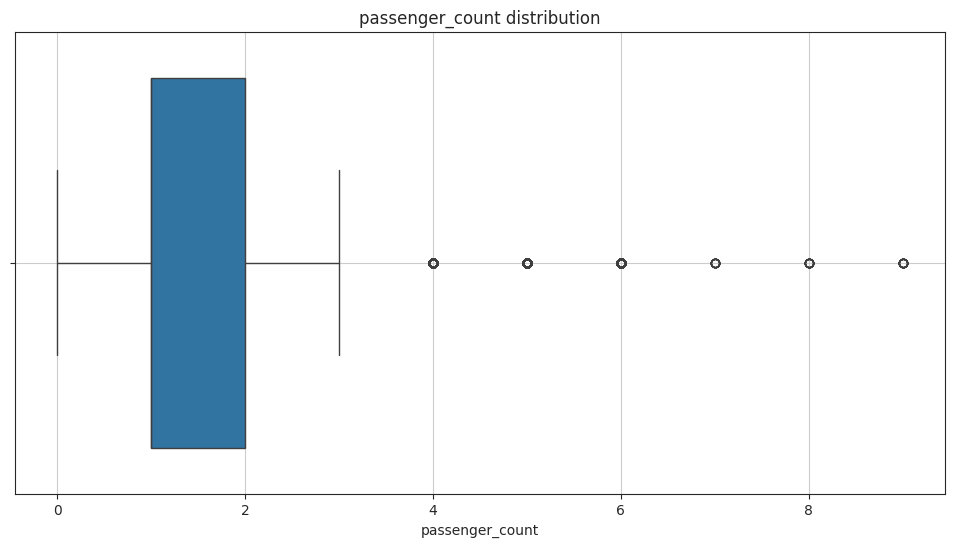

In [120]:
passenger_count = lf.select("passenger_count").collect()

plt.figure(figsize=(12, 6))
sns.boxplot(data=passenger_count, x="passenger_count")
plt.title("passenger_count distribution")
plt.grid(True)
plt.show()

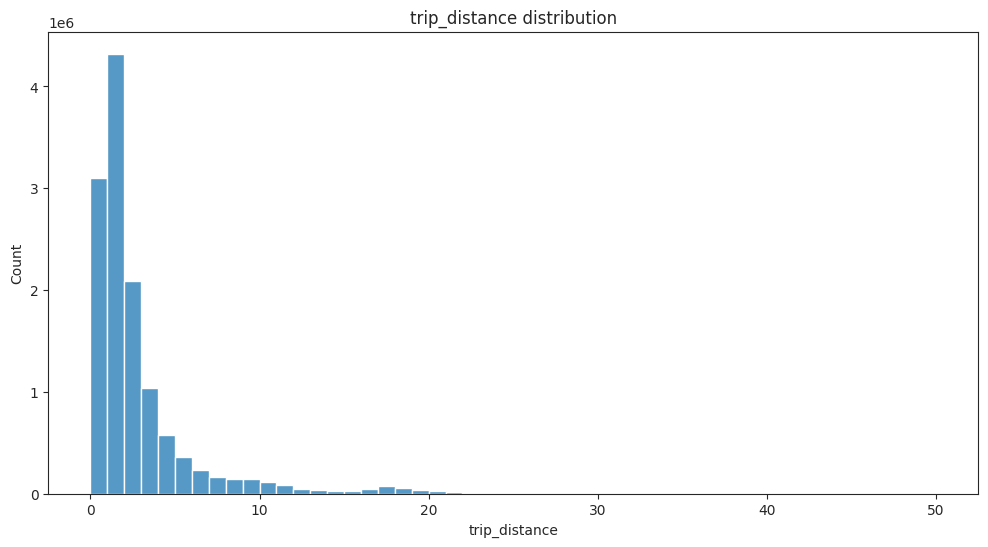

In [119]:
trip_distance = (
    lf.select("trip_distance")
    .filter(pl.col("trip_distance").is_between(0, 50))
    .collect()
)

plt.figure(figsize=(12, 6))
sns.histplot(data=trip_distance, x="trip_distance", bins=50)
plt.title("trip_distance distribution")
plt.show()

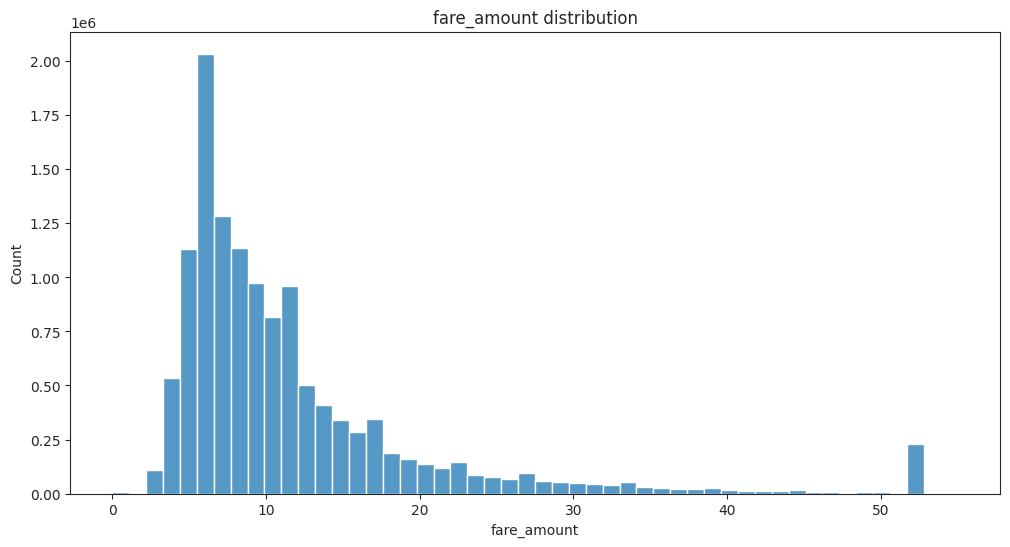

In [118]:
fare_amount = (
    lf.select("fare_amount")
    .filter(pl.col("fare_amount").is_between(0, 55))
    .collect()
)

plt.figure(figsize=(12, 6))
sns.histplot(data=fare_amount, x="fare_amount", bins=50)
plt.title("fare_amount distribution")
plt.show()

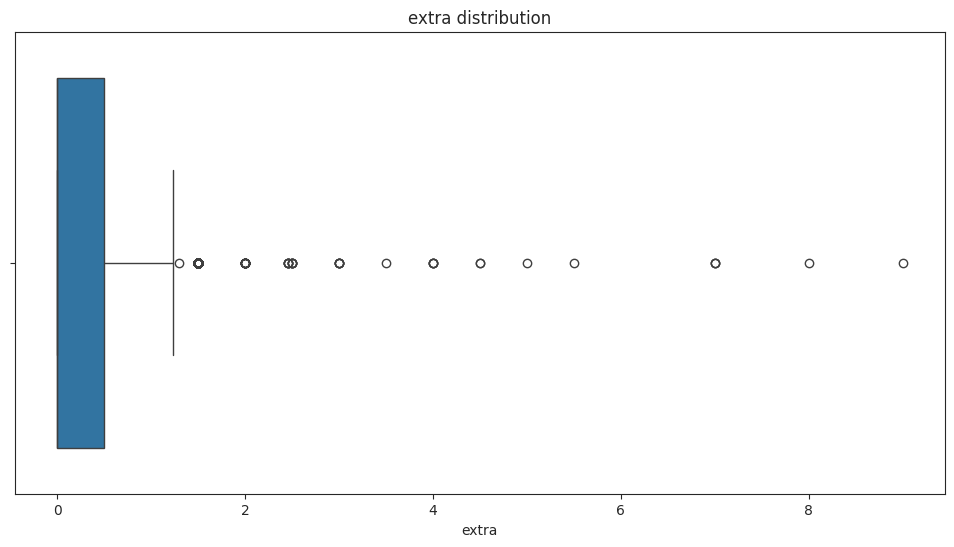

In [117]:
extra = (
    lf.select("extra")
    .filter(pl.col("extra").is_between(0, 10))
    .collect()
)

plt.figure(figsize=(12, 6))
sns.boxplot(data=extra, x="extra")
plt.title("extra distribution")
plt.show()

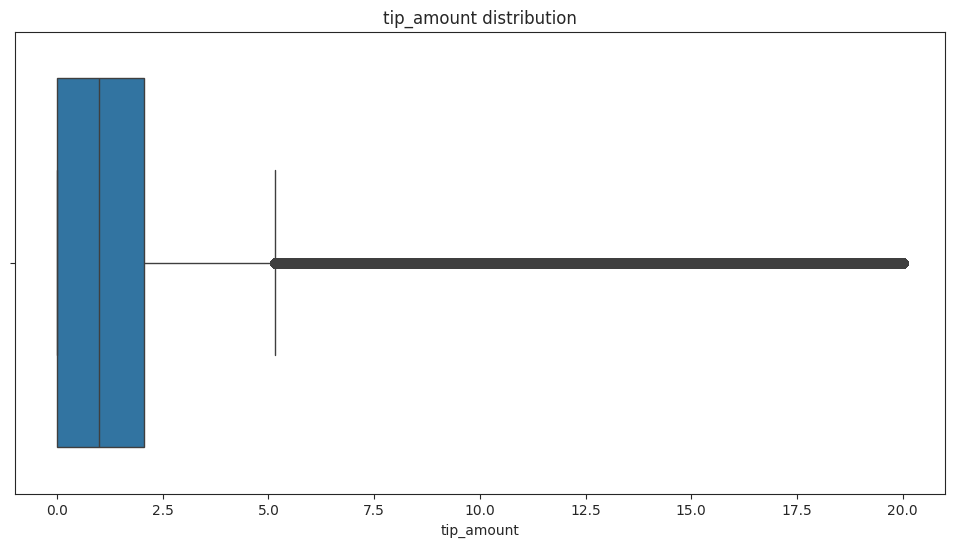

In [116]:
tip_amount = (
    lf.select("tip_amount")
    .filter(pl.col("tip_amount").is_between(0, 20))
    .collect()
)

plt.figure(figsize=(12, 6))
sns.boxplot(data=tip_amount, x="tip_amount")
plt.title("tip_amount distribution")
plt.show()

KeyboardInterrupt: 

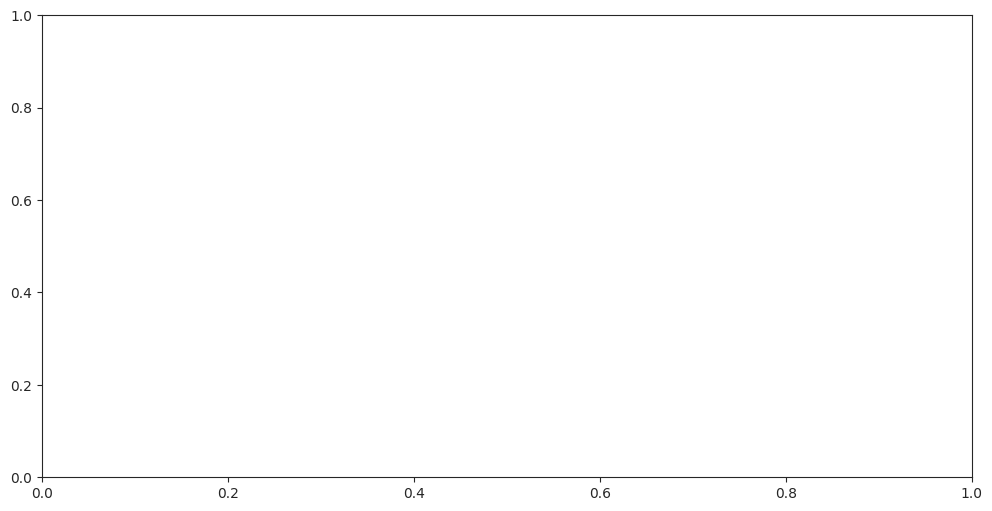

In [115]:
tolls_amount = (
    lf.select("tolls_amount")
    .filter(pl.col("tolls_amount").is_between(0, 10))
    .collect()
)

plt.figure(figsize=(12, 6))
sns.boxplot(data=tolls_amount, x="tolls_amount")
plt.title("tolls_amount distribution")
plt.show()

In [6]:
lf.filter(pl.col("improvement_surcharge").is_null()).collect()

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
i64,str,str,i64,f64,f64,f64,i64,str,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64
1,"""2015-01-02 08:46:23""","""2015-01-02 09:09:26""",1,3.6,0.0,0.0,1,"""N""",0.0,0.0,1,17.0,0.0,0.5,3.5,0.0,null,21.0
1,"""2015-01-02 09:13:32""","""2015-01-02 09:35:25""",1,2.2,0.0,0.0,1,"""N""",0.0,0.0,1,14.5,0.0,0.5,3.0,0.0,null,18.0
1,"""2015-01-02 09:52:43""","""2015-01-02 10:22:02""",1,2.1,0.0,0.0,1,"""N""",0.0,0.0,1,18.0,0.0,0.5,3.7,0.0,null,22.2


In [7]:
lf.filter((pl.col("trip_distance") == 0) | (pl.col("total_amount") == 0)).head().collect()

VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
i64,str,str,i64,f64,f64,f64,i64,str,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64
1,"""2015-01-15 10:26:16""","""2015-01-15 10:26:42""",2,0.0,-73.987656,40.743645,5,"""N""",-73.987488,40.743484,1,60.0,0.0,0.0,15.0,0.0,0.3,75.3
1,"""2015-01-15 10:26:17""","""2015-01-15 10:27:28""",1,0.0,-73.946526,40.744991,1,"""N""",-73.946526,40.744991,2,3.0,0.0,0.5,0.0,0.0,0.3,3.8
1,"""2015-01-01 01:08:56""","""2015-01-01 01:08:56""",4,0.0,-73.980789,40.676605,1,"""Y""",0.0,0.0,2,20.0,0.5,0.5,0.0,0.0,0.0,21.3
2,"""2015-01-25 17:45:15""","""2015-01-25 17:45:21""",1,0.0,-73.975655,40.761318,2,"""N""",0.0,0.0,1,52.0,0.0,0.5,20.0,0.0,0.3,72.8
1,"""2015-01-10 20:14:23""","""2015-01-10 20:14:36""",1,0.0,-73.993271,40.748833,1,"""N""",-73.993271,40.748833,3,2.5,0.5,0.5,0.0,0.0,0.3,3.8


### 3. Data transformation

In [ ]:
df_silver = (
    lf.rename({
        "VendorID": "vendor_id",
        "RateCodeID": "rate_code_id"
    })
    .filter(pl.col("passenger_count") <= 4)
    .filter(pl.col("trip_distance") <= 10)
    .filter(pl.col("pickup_longitude").is_between(-180, 180))
    .filter(pl.col("pickup_latitude").is_between(-90, 90))
    .filter(pl.col("rate_code_id").is_in(range(1,7)))
    .filter(pl.col("dropoff_longitude").is_between(-180, 180))
    .filter(pl.col("dropoff_latitude").is_between(-90, 90))
    .filter(pl.col("fare_amount").is_between(0, 55))
    .filter(pl.col("extra").is_between(0, 2))
    .filter(pl.col("mta_tax") >= 0)
    .filter(pl.col("tip_amount").is_between(0, 5))
    .filter(pl.col("tolls_amount").is_between(0, 1))
    .filter(pl.col("total_amount") >= 0)
    .drop_nulls()
    .with_columns(
        pl.col("tpep_pickup_datetime").str.to_datetime().alias("tpep_pickup_datetime"),
        pl.col("tpep_dropoff_datetime").str.to_datetime().alias("tpep_dropoff_datetime")
    )
    .filter(
        (pl.col("tpep_pickup_datetime").is_between(
            datetime(2015, 1, 1), datetime(2015, 1, 31, 23, 59, 59)
        )) &
        (pl.col("tpep_dropoff_datetime").is_between(
            datetime(2015, 1, 1), datetime(2015, 1, 31, 23, 59, 59)
        ))
    )
    .collect()
)

bronze_size = lf.select(pl.len()).collect().item()
silver_size = df_silver.shape[0]

print(f"Bronze size: {bronze_size}")
print(f"Silver size: {silver_size}")
print(f"Filtered rows: {bronze_size - silver_size}")

Bronze size: 12748986
Silver size: 10657811
Filtered rows: 2091175


In [102]:
df_silver.head()

vendor_id,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,rate_code_id,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
i64,datetime[μs],datetime[μs],i64,f64,f64,f64,i64,str,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64
2,2015-01-15 19:05:39,2015-01-15 19:23:42,1,1.59,-73.993896,40.750111,1,"""N""",-73.974785,40.750618,1,12.0,1.0,0.5,3.25,0.0,0.3,17.05
1,2015-01-10 20:33:38,2015-01-10 20:53:28,1,3.3,-74.001648,40.724243,1,"""N""",-73.994415,40.759109,1,14.5,0.5,0.5,2.0,0.0,0.3,17.8
1,2015-01-10 20:33:38,2015-01-10 20:43:41,1,1.8,-73.963341,40.802788,1,"""N""",-73.95182,40.824413,2,9.5,0.5,0.5,0.0,0.0,0.3,10.8
1,2015-01-10 20:33:39,2015-01-10 20:35:31,1,0.5,-74.009087,40.713818,1,"""N""",-74.004326,40.719986,2,3.5,0.5,0.5,0.0,0.0,0.3,4.8
1,2015-01-10 20:33:39,2015-01-10 20:52:58,1,3.0,-73.971176,40.762428,1,"""N""",-74.004181,40.742653,2,15.0,0.5,0.5,0.0,0.0,0.3,16.3


In [103]:
df_silver.describe()

statistic,vendor_id,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,rate_code_id,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
str,f64,str,str,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",1.0657811e7,"""10657811""","""10657811""",1.0657811e7,1.0657811e7,1.0657811e7,1.0657811e7,1.0657811e7,"""10657811""",1.0657811e7,1.0657811e7,1.0657811e7,1.0657811e7,1.0657811e7,1.0657811e7,1.0657811e7,1.0657811e7,1.0657811e7,1.0657811e7
"""null_count""",0.0,"""0""","""0""",0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",1.473159,"""2015-01-16 15:11:11.080625""","""2015-01-16 15:22:43.363891""",1.310579,2.006568,-72.503746,39.939624,1.006034,null,-72.558026,39.971021,1.39956,9.687226,0.313273,0.499353,1.166457,0.000019,0.281734,11.96581
"""std""",0.499279,null,null,0.661202,1.549518,10.34465,5.698524,0.148063,null,10.148884,5.590873,0.501312,5.0146,0.363034,0.017974,1.221501,0.003714,0.071736,5.565978
"""min""",1.0,"""2015-01-01 00:00:00""","""2015-01-01 00:00:00""",0.0,0.0,-121.925812,0.0,1.0,"""N""",-97.410072,-9.029157,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",1.0,"""2015-01-09 10:09:58""","""2015-01-09 10:23:39""",1.0,0.94,-73.991959,40.736691,1.0,null,-73.991394,40.735867,1.0,6.0,0.0,0.5,0.0,0.0,0.3,7.8
"""50%""",1.0,"""2015-01-16 12:16:37""","""2015-01-16 12:29:24""",1.0,1.52,-73.982079,40.753269,1.0,null,-73.980469,40.753899,1.0,8.5,0.0,0.5,1.0,0.0,0.3,10.56
"""75%""",2.0,"""2015-01-23 19:40:06""","""2015-01-23 19:52:19""",1.0,2.57,-73.968552,40.76709,1.0,null,-73.964973,40.768536,2.0,12.0,0.5,0.5,2.0,0.0,0.3,14.75
"""max""",2.0,"""2015-01-31 23:59:21""","""2015-01-31 23:59:59""",4.0,10.0,78.662651,82.498009,6.0,"""Y""",85.274025,82.498009,5.0,55.0,2.0,0.5,5.0,1.0,0.3,124.96


### 4. Silver data loading

In [104]:
silver_path = Path().cwd().parent / "data" / "silver" / bronze_path.with_suffix(".parquet").name

df_silver.write_parquet(silver_path)

### 5. Gold

In [ ]:
gold_columns = {
    "vendor_id": {
        1: "Creative Mobile Technologies",
        2: "VeriFone Inc."
    },
    "rate_code_id": {
        1: "Standard rate",
        2: "JFK",
        3: "Newark",
        4: "Nassau or Westchester",
        5: "Negotiated fare",
        6: "Group ride",
    },
    "payment_type": {
        1: "Credit card",
        2: "Cash",
        3: "No charge",
        4: "Dispute",
        5: "Unknown",
        6: "Voided trip"
    }
}